# NanoPitch Dataset Visualization

The dataset ships as **pre-extracted log-mel features**, not raw audio. Three files:

| File | Fields | Purpose |
|---|---|---|
| `clean.npz` | `mel (N,40)`, `f0 (N,)`, `vad (N,)`, `lengths (K,)` | Clean vocals, concatenated; `lengths` gives per-clip boundaries |
| `noise.npz` | `mel (N,40)`, `lengths (K,)` | Noise pool for on-the-fly SNR mixing |
| `test.npz`  | `clips (N,T,40)`, `f0 (N,T)`, `vad (N,T)`, `snr (N,)` | Pre-mixed eval clips at fixed SNRs |

**Feature config:** 16 kHz sample rate, 10 ms hop, 40 mel bands, 512-pt FFT.

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = os.path.abspath(os.path.join(os.getcwd(), '..', 'data'))
SR = 16000
HOP = 160           # samples
FRAME_MS = 1000 * HOP / SR  # 10 ms

print('Data dir:', DATA_DIR)
print('Files:', sorted(f for f in os.listdir(DATA_DIR) if f.endswith('.npz')))

Data dir: /home/sraja/NanoPitch-MusicalAI/data
Files: ['clean.npz', 'noise.npz', 'test.npz']


## 1. Load and inspect schema

In [4]:
clean = np.load(os.path.join(DATA_DIR, 'clean.npz'))
noise = np.load(os.path.join(DATA_DIR, 'noise.npz'))
test  = np.load(os.path.join(DATA_DIR, 'test.npz'))

def describe(name, npz):
    print(f'--- {name} ---')
    for k in npz.files:
        a = npz[k]
        print(f'  {k:10s} shape={tuple(a.shape)!s:<20s} dtype={a.dtype}  range=[{a.min():.3f}, {a.max():.3f}]')

for n, d in [('clean', clean), ('noise', noise), ('test', test)]:
    describe(n, d)
    print()

--- clean ---
  mel        shape=(36372498, 40)       dtype=float16  range=[-23.031, 9.820]
  f0         shape=(36372498,)          dtype=float16  range=[0.000, 1014.500]
  vad        shape=(36372498,)          dtype=float16  range=[0.000, 1.000]
  lengths    shape=(40940,)             dtype=int32  range=[102.000, 3508.000]

--- noise ---
  mel        shape=(15283949, 40)       dtype=float16  range=[-23.031, 10.297]
  lengths    shape=(17616,)             dtype=int32  range=[51.000, 3003.000]

--- test ---
  clips      shape=(600, 500, 40)       dtype=float16  range=[-22.062, 10.297]
  clean      shape=(600, 500, 40)       dtype=float16  range=[-23.031, 9.453]
  f0         shape=(600, 500)           dtype=float16  range=[0.000, 677.000]
  vad        shape=(600, 500)           dtype=float16  range=[0.000, 1.000]
  snr        shape=(600,)               dtype=float32  range=[-5.000, inf]
  snr_levels shape=(6,)                 dtype=float32  range=[-5.000, inf]
  clip_len   shape=()      

In [5]:
clean_mel, clean_f0, clean_vad, clean_lens = clean['mel'], clean['f0'], clean['vad'], clean['lengths']
noise_mel, noise_lens = noise['mel'], noise['lengths']
test_clips, test_f0, test_vad, test_snr = test['clips'], test['f0'], test['vad'], test['snr']

total_hours = clean_mel.shape[0] * FRAME_MS / 1000 / 3600
noise_hours = noise_mel.shape[0] * FRAME_MS / 1000 / 3600
print(f'Clean: {len(clean_lens)} clips, {total_hours:.2f} hours, voiced frac = {clean_vad.mean():.3f}')
print(f'Noise: {len(noise_lens)} clips, {noise_hours:.2f} hours')
print(f'Test:  {len(test_clips)} clips x {test_clips.shape[1]} frames, SNRs = {sorted(set(test_snr.tolist()))}')

Clean: 40940 clips, 101.03 hours, voiced frac = 0.618
Noise: 17616 clips, 42.46 hours
Test:  600 clips x 500 frames, SNRs = [-5.0, 0.0, 5.0, 10.0, 20.0, inf]


## 2. Dataset-level distributions

Clip lengths, voiced fraction per clip, and the pitch distribution over voiced frames.

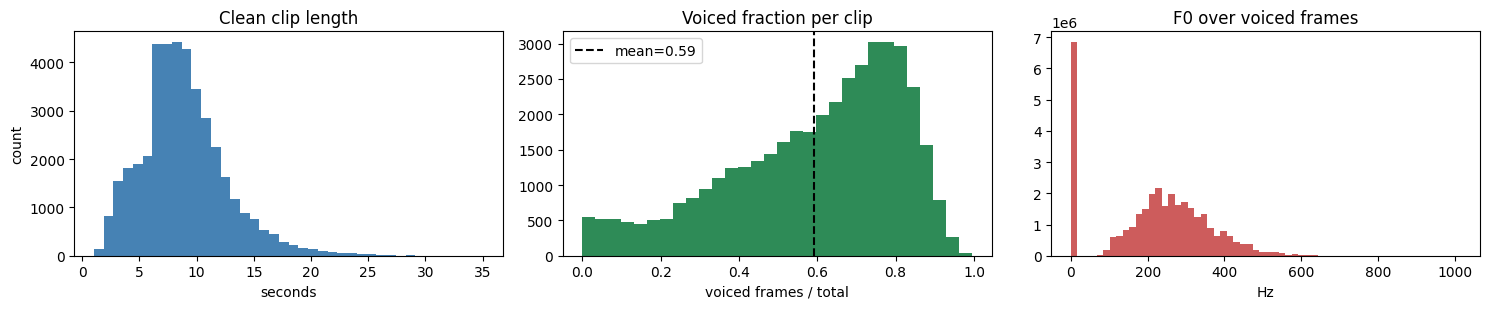

In [6]:
def clip_slices(lengths):
    offs = np.concatenate([[0], np.cumsum(lengths)])
    return [(int(offs[i]), int(offs[i+1])) for i in range(len(lengths))]

clean_slices = clip_slices(clean_lens)
voiced_frac = np.array([clean_vad[s:e].mean() for s, e in clean_slices])
clip_seconds = clean_lens * FRAME_MS / 1000

fig, axs = plt.subplots(1, 3, figsize=(15, 3.2))
axs[0].hist(clip_seconds, bins=40, color='steelblue')
axs[0].set(title='Clean clip length', xlabel='seconds', ylabel='count')
axs[1].hist(voiced_frac, bins=30, color='seagreen')
axs[1].set(title='Voiced fraction per clip', xlabel='voiced frames / total')
axs[1].axvline(voiced_frac.mean(), color='k', ls='--', label=f'mean={voiced_frac.mean():.2f}')
axs[1].legend()
voiced_f0 = clean_f0[clean_vad > 0]
axs[2].hist(voiced_f0, bins=60, color='indianred')
axs[2].set(title='F0 over voiced frames', xlabel='Hz')
plt.tight_layout(); plt.show()

The voiced-fraction histogram is the motivation for balanced sampling in `train.py` — clips skew toward 30–60% voiced, but plain uniform sampling undersamples the voiced regime the pitch head needs.

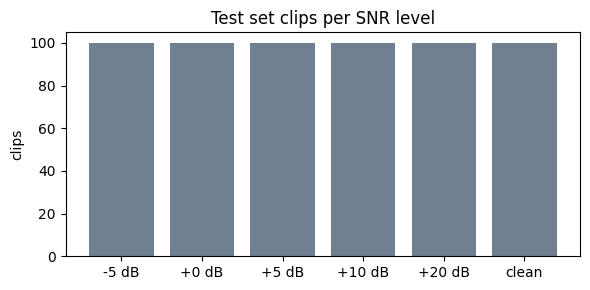

In [7]:
fig, ax = plt.subplots(figsize=(6, 3))
unique_snr, counts = np.unique(np.where(np.isfinite(test_snr), test_snr, 999), return_counts=True)
labels = ['clean' if s == 999 else f'{int(s):+d} dB' for s in unique_snr]
ax.bar(labels, counts, color='slategray')
ax.set(title='Test set clips per SNR level', ylabel='clips')
plt.tight_layout(); plt.show()

## 3. Per-clip view: mel + f0 + VAD

Each panel shows one clip. Change `clip_idx` to browse.

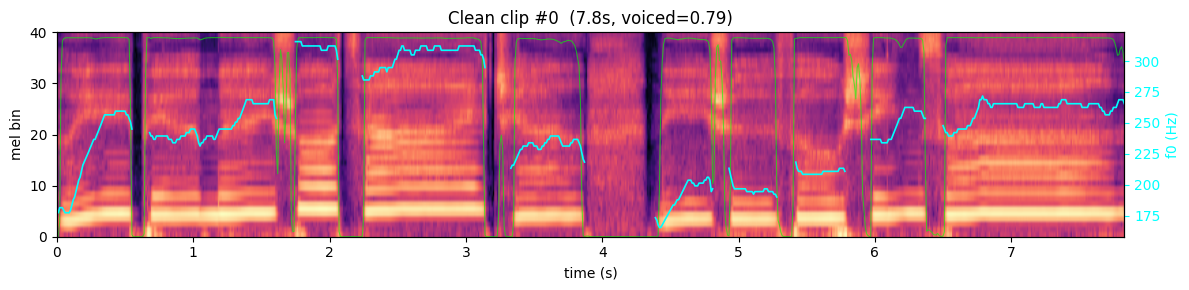

In [8]:
def plot_clip(mel, f0=None, vad=None, title='', ax=None):
    created = ax is None
    if created:
        fig, ax = plt.subplots(figsize=(12, 3))
    T = mel.shape[0]
    t = np.arange(T) * FRAME_MS / 1000
    im = ax.imshow(mel.T, origin='lower', aspect='auto',
                   extent=[t[0], t[-1], 0, mel.shape[1]], cmap='magma')
    ax.set(ylabel='mel bin', title=title)
    if f0 is not None:
        f0_plot = np.where(f0 > 0, f0, np.nan)
        ax2 = ax.twinx()
        ax2.plot(t, f0_plot, color='cyan', lw=1.2, label='f0 (Hz)')
        ax2.set_ylabel('f0 (Hz)', color='cyan')
        ax2.tick_params(axis='y', colors='cyan')
    if vad is not None:
        ax.plot(t, vad * (mel.shape[1] - 1), color='lime', lw=0.8, alpha=0.6, label='VAD')
    ax.set_xlabel('time (s)')
    if created:
        plt.tight_layout(); plt.show()

clip_idx = 0
s, e = clean_slices[clip_idx]
plot_clip(clean_mel[s:e], clean_f0[s:e], clean_vad[s:e],
          title=f'Clean clip #{clip_idx}  ({(e-s)*FRAME_MS/1000:.1f}s, voiced={clean_vad[s:e].mean():.2f})')

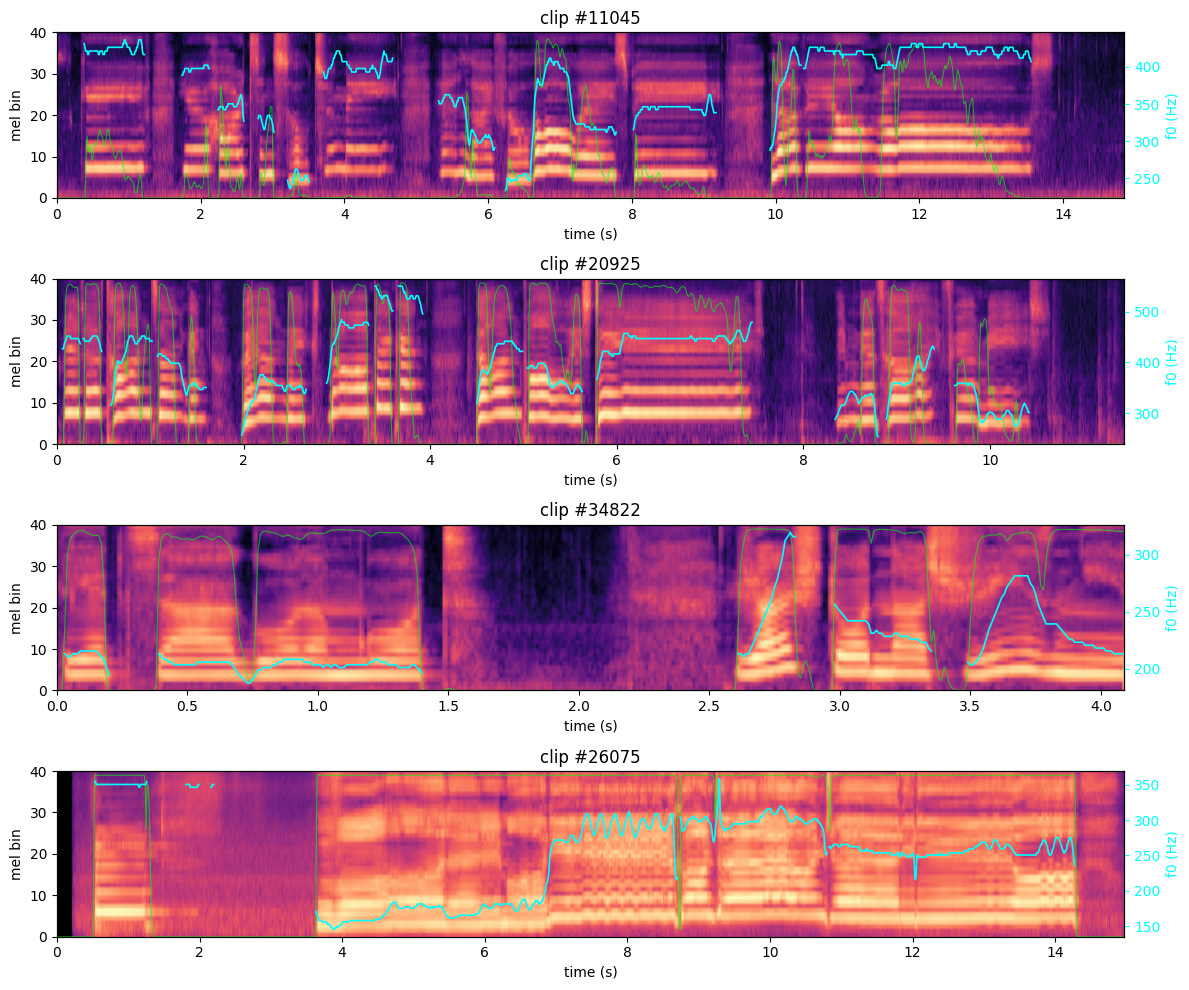

In [9]:
rng = np.random.default_rng(0)
sample = rng.choice(len(clean_slices), size=4, replace=False)
fig, axs = plt.subplots(4, 1, figsize=(12, 10))
for ax, idx in zip(axs, sample):
    s, e = clean_slices[idx]
    plot_clip(clean_mel[s:e], clean_f0[s:e], clean_vad[s:e],
              title=f'clip #{idx}', ax=ax)
plt.tight_layout(); plt.show()

## 4. Noise pool

Noise is stored in the same log-mel form. No f0 / VAD labels — it is only mixed into clean during training via `torch.logaddexp`.

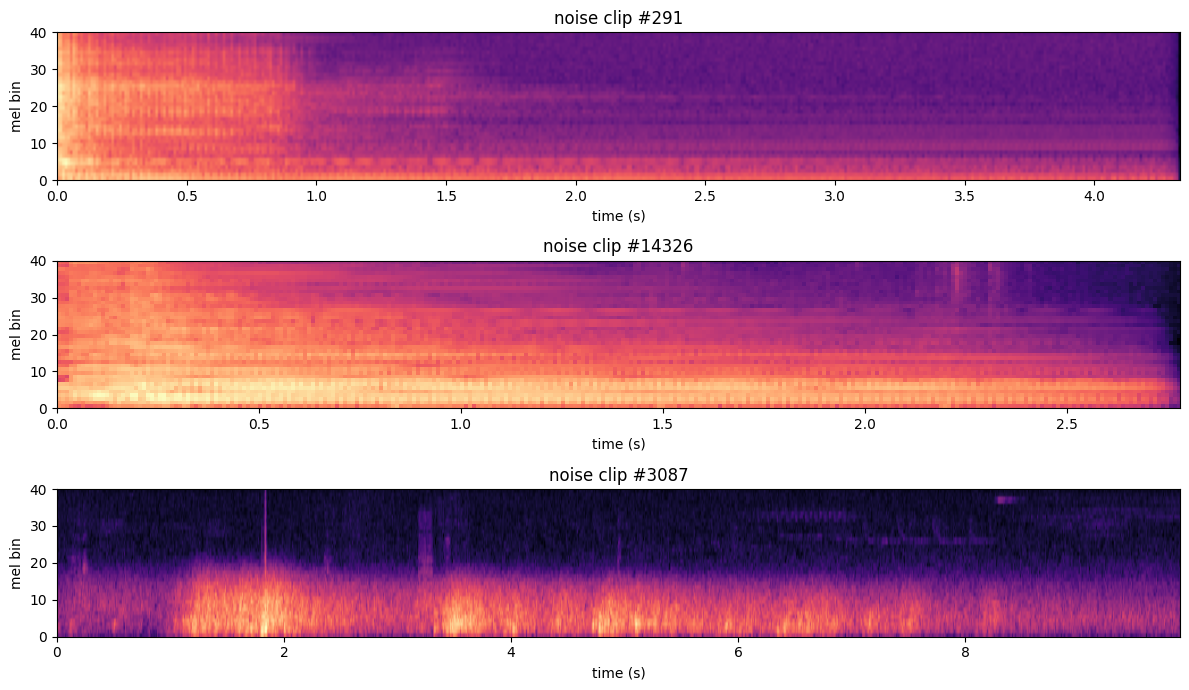

In [10]:
noise_slices = clip_slices(noise_lens)
fig, axs = plt.subplots(3, 1, figsize=(12, 7))
for ax, idx in zip(axs, rng.choice(len(noise_slices), size=3, replace=False)):
    s, e = noise_slices[idx]
    plot_clip(noise_mel[s:e], title=f'noise clip #{idx}', ax=ax)
plt.tight_layout(); plt.show()

## 5. SNR mixing in the mel domain

Training mixes clean + noise mel via `logaddexp(clean, noise + offset)`, where `offset` is chosen to hit a target SNR. Below we visualize the same clean clip mixed at several SNRs against one noise sample to see what the model actually sees at eval-time SNRs.

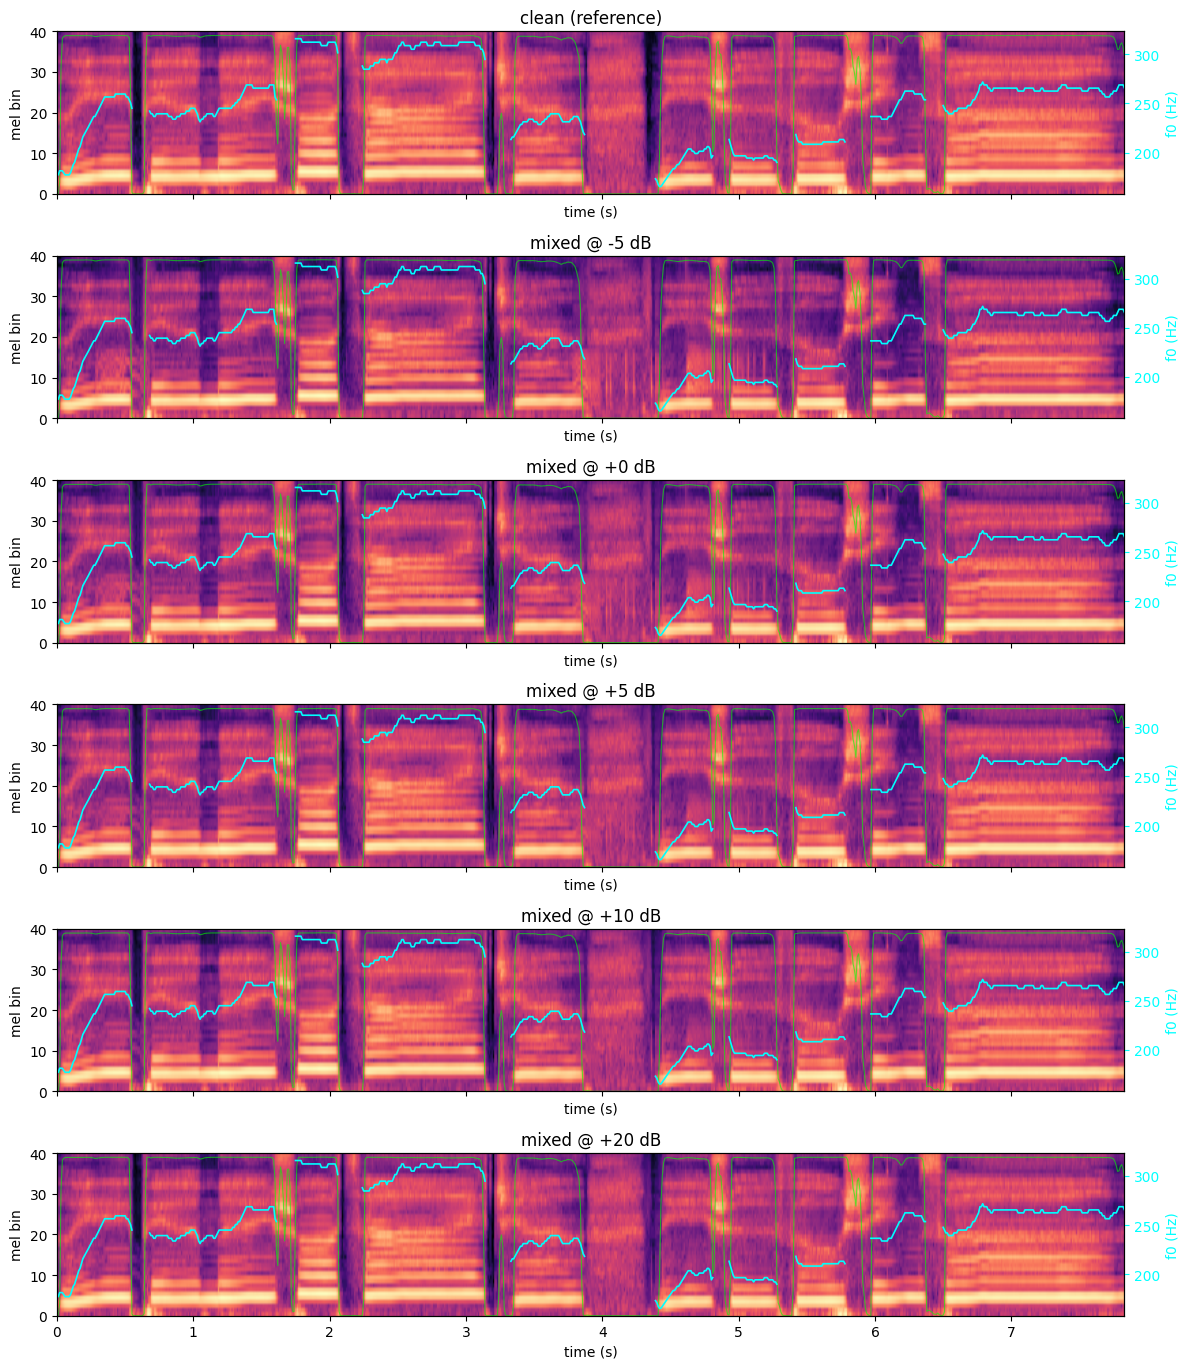

In [11]:
def mix_logmel(clean_db, noise_db, snr_db):
    # clean and noise are log-mel (natural-log, up to a constant). Energy ratio in
    # dB translates linearly in log-mel, so shift noise by -snr_db / 10 * ln(10).
    shift = -snr_db / 10.0 * np.log(10.0)
    return np.logaddexp(clean_db, noise_db + shift)

s, e = clean_slices[0]
clip_len = e - s
ns, ne = noise_slices[0]
noise_seg = noise_mel[ns:ns + clip_len]
clean_seg = clean_mel[s:e]

snrs_to_plot = [-5, 0, 5, 10, 20]
fig, axs = plt.subplots(len(snrs_to_plot) + 1, 1, figsize=(12, 2.3 * (len(snrs_to_plot) + 1)), sharex=True)
plot_clip(clean_seg, clean_f0[s:e], clean_vad[s:e], title='clean (reference)', ax=axs[0])
for ax, snr in zip(axs[1:], snrs_to_plot):
    mixed = mix_logmel(clean_seg, noise_seg, snr)
    plot_clip(mixed, clean_f0[s:e], clean_vad[s:e], title=f'mixed @ {snr:+d} dB', ax=ax)
plt.tight_layout(); plt.show()

## 6. Test set clips by SNR

Test clips are pre-mixed. Pick one clip per SNR bucket to see what the evaluation harness feeds the model.

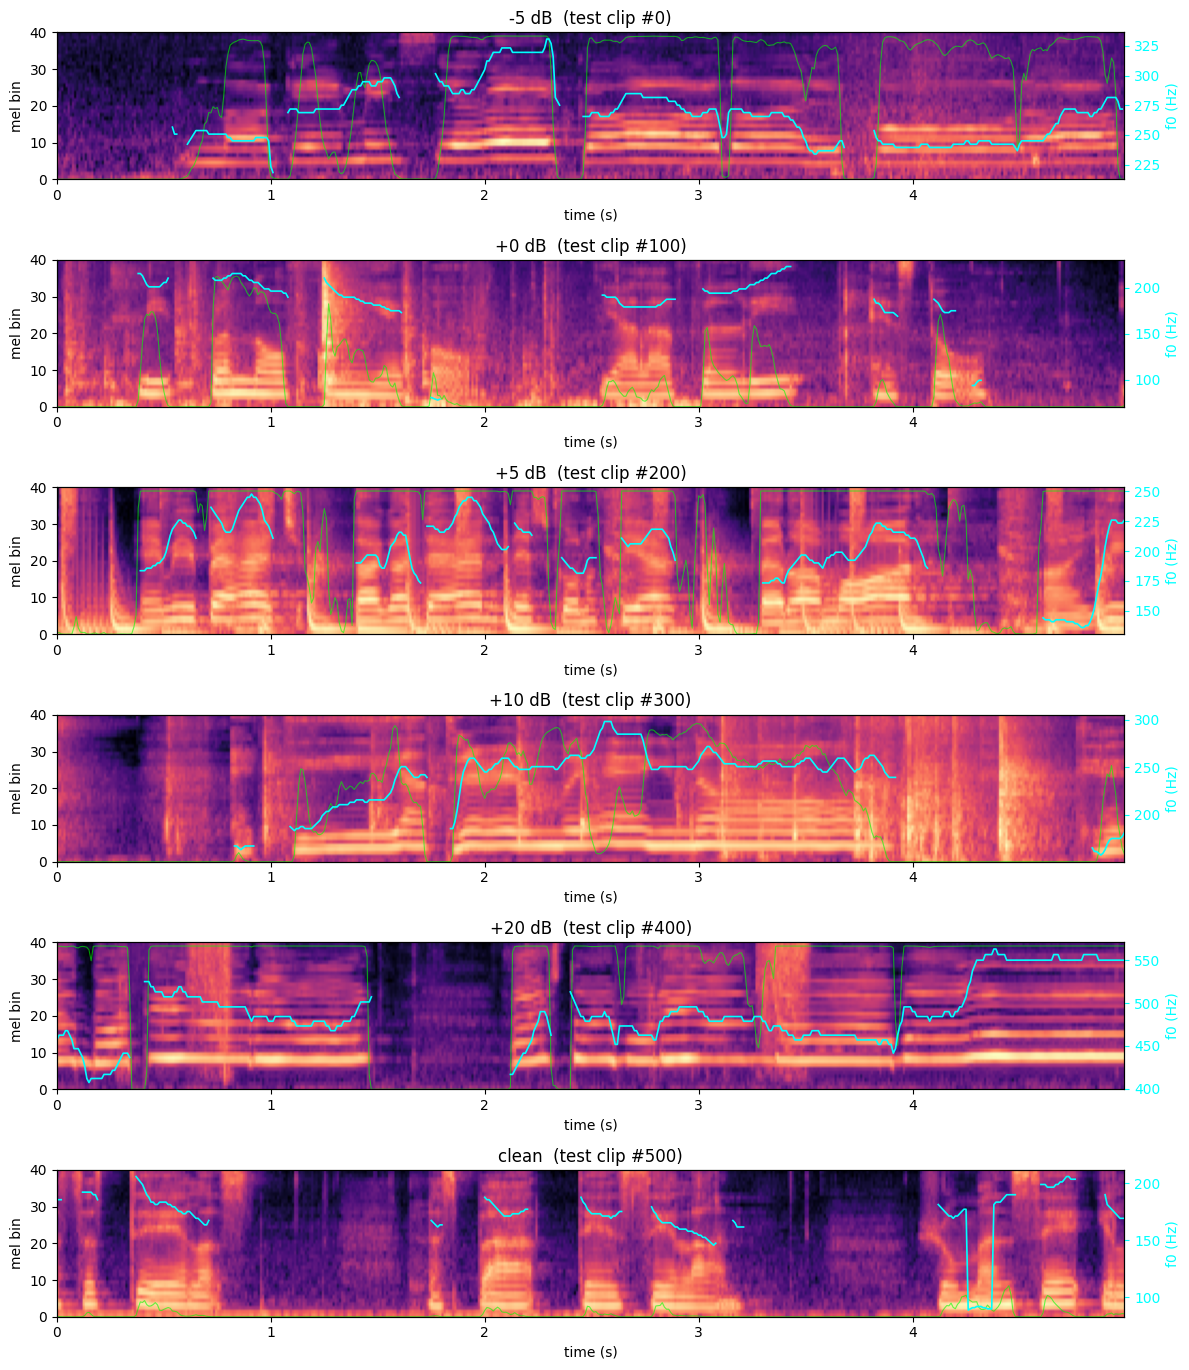

In [12]:
def snr_label(v):
    return 'clean' if not np.isfinite(v) else f'{int(v):+d} dB'

buckets = {}
for i, s in enumerate(test_snr):
    buckets.setdefault(snr_label(s), []).append(i)

order = ['-5 dB', '+0 dB', '+5 dB', '+10 dB', '+20 dB', 'clean']
order = [k for k in order if k in buckets]

fig, axs = plt.subplots(len(order), 1, figsize=(12, 2.3 * len(order)))
for ax, label in zip(axs, order):
    idx = buckets[label][0]
    plot_clip(test_clips[idx].astype(np.float32), test_f0[idx].astype(np.float32), test_vad[idx].astype(np.float32),
              title=f'{label}  (test clip #{idx})', ax=ax)
plt.tight_layout(); plt.show()

## 7. VAD label sanity check

Training VAD targets are RMS-based (`clean.npz['vad']`) while eval VAD labels come from the test pipeline. Compare how often `f0 > 0` agrees with the stored `vad` flag, on both clean and test. Divergence here is the known train/eval VAD mismatch documented in `IMPROVEMENTS.md`.

In [13]:
def vad_vs_f0(vad, f0, name):
    v = vad > 0.5
    p = f0 > 0
    agree = (v == p).mean()
    only_vad = (v & ~p).mean()
    only_f0  = (~v & p).mean()
    print(f'{name:10s}  agree={agree:.3f}  vad=1 & f0=0 -> {only_vad:.3f}  vad=0 & f0>0 -> {only_f0:.3f}')

vad_vs_f0(clean_vad, clean_f0, 'clean')
vad_vs_f0(test_vad.reshape(-1), test_f0.reshape(-1), 'test')

clean       agree=0.879  vad=1 & f0=0 -> 0.015  vad=0 & f0>0 -> 0.106
test        agree=0.818  vad=1 & f0=0 -> 0.021  vad=0 & f0>0 -> 0.161
